In [11]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_file_path = os.path.join(path, "creditcard.csv")


Path to dataset files: C:\Users\Karan\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3
C:\Users\Karan\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv


## Initial Data Inspection
We begin by examining the structure, data types, and basic statistics of the dataset.


In [29]:
df = pd.read_csv(csv_file_path)
print(df.describe())
print(df.info())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

## Target Variable Distribution

Fraud detection datasets are typically highly imbalanced.  
Understanding the degree of imbalance informs modeling and evaluation choices.

In [32]:
class_counts = df["Class"].value_counts()
fraud_count = class_counts[1]
normal_count = class_counts[0]
total_count = len(df)

fraud_pct = (fraud_count / total_count) * 100
imbalance_ratio = normal_count / fraud_count

print("\n" + "─" * 70)
print("Class Distribution:")
print("─" * 70)
print(f"  Normal (Class 0): {normal_count:>10,} ({100-fraud_pct:>6.3f}%)")
print(f"  Fraud  (Class 1): {fraud_count:>10,} ({fraud_pct:>6.3f}%)")
print(f"  {'─' * 68}")
print(f"  Total:            {total_count:>10,} (100.000%)")
print(f"\n  Imbalance Ratio: {imbalance_ratio:.1f}:1 (Normal:Fraud)")



──────────────────────────────────────────────────────────────────────
Class Distribution:
──────────────────────────────────────────────────────────────────────
  Normal (Class 0):    284,315 (99.827%)
  Fraud  (Class 1):        492 ( 0.173%)
  ────────────────────────────────────────────────────────────────────
  Total:               284,807 (100.000%)

  Imbalance Ratio: 577.9:1 (Normal:Fraud)


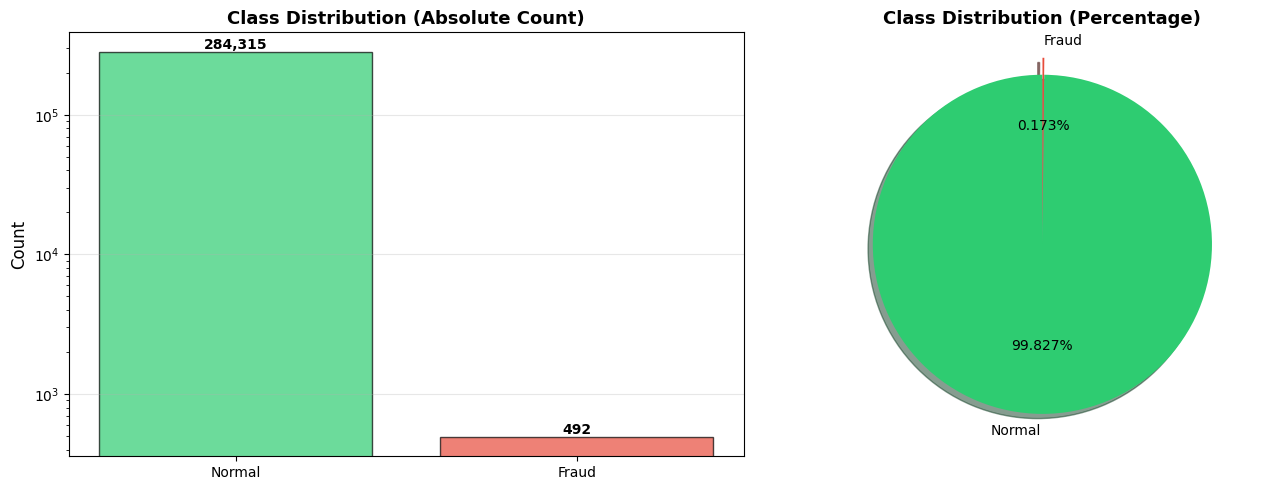

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(['Normal', 'Fraud'], [normal_count, fraud_count], 
            color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Class Distribution (Absolute Count)', fontsize=13, fontweight='bold')
axes[0].set_yscale('log')
axes[0].grid(axis='y', alpha=0.3)
for i, (label, count) in enumerate(zip(['Normal', 'Fraud'], [normal_count, fraud_count])):
    axes[0].text(i, count, f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)
axes[1].pie([normal_count, fraud_count], labels=['Normal', 'Fraud'], autopct='%1.3f%%',
            colors=colors, explode=explode, shadow=True, startangle=90)
axes[1].set_title('Class Distribution (Percentage)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('phase1_class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()


──────────────────────────────────────────────────────────────────────
Transaction Amount Statistics by Class:
──────────────────────────────────────────────────────────────────────
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


C:\Users\Karan\AppData\Local\Temp\ipykernel_30460\1843220329.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([df[df["Class"] == 0]['Amount'],


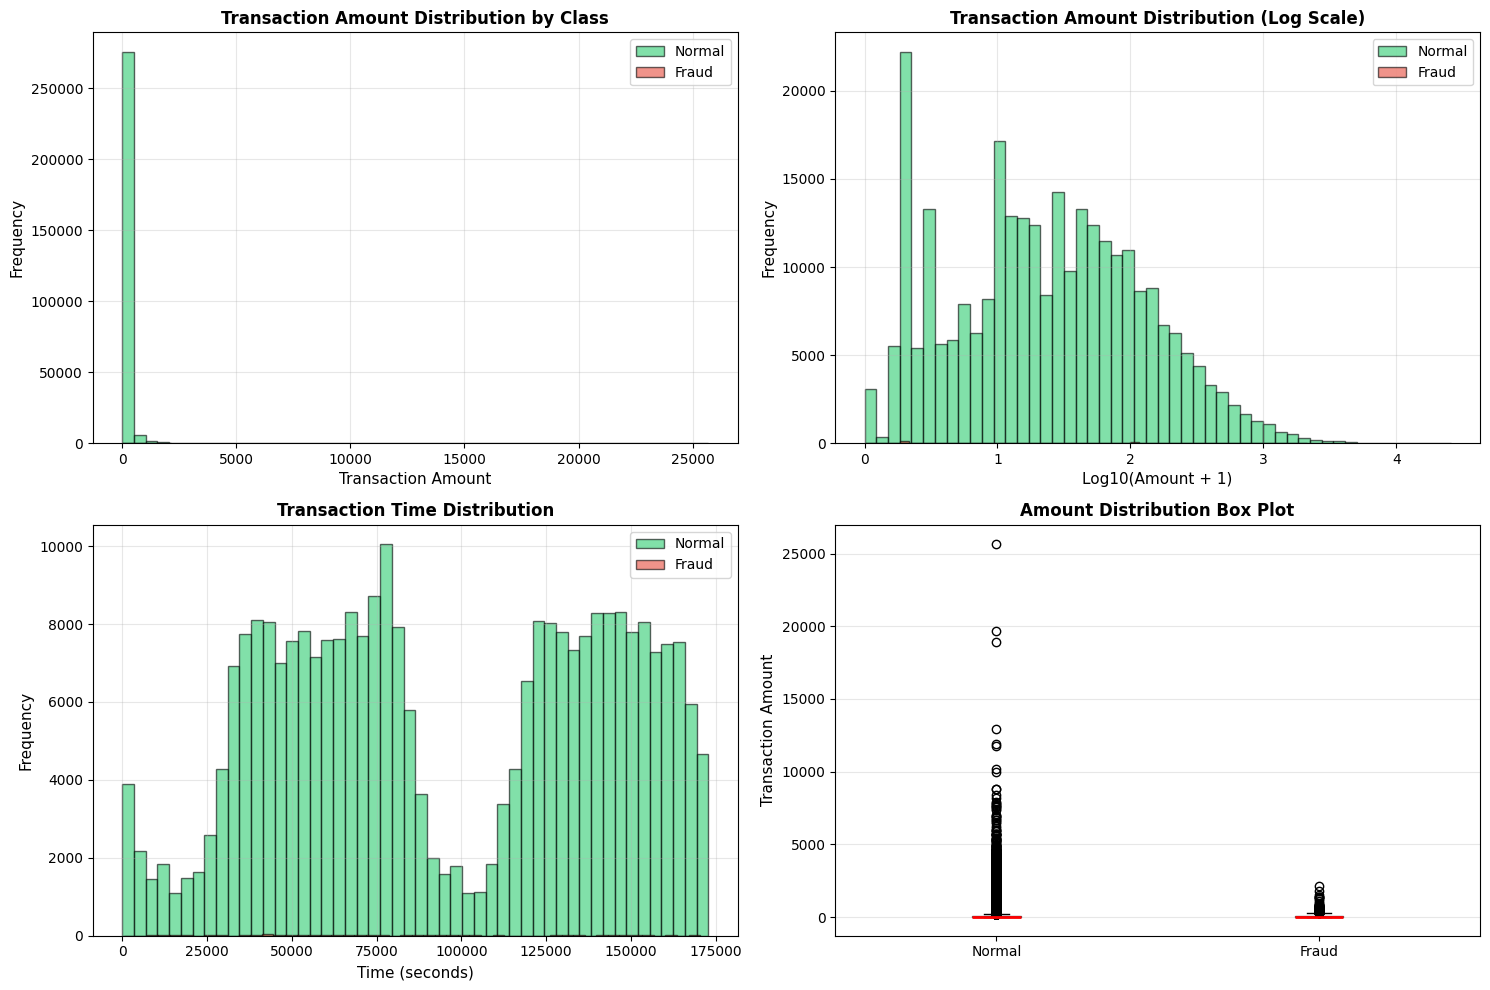

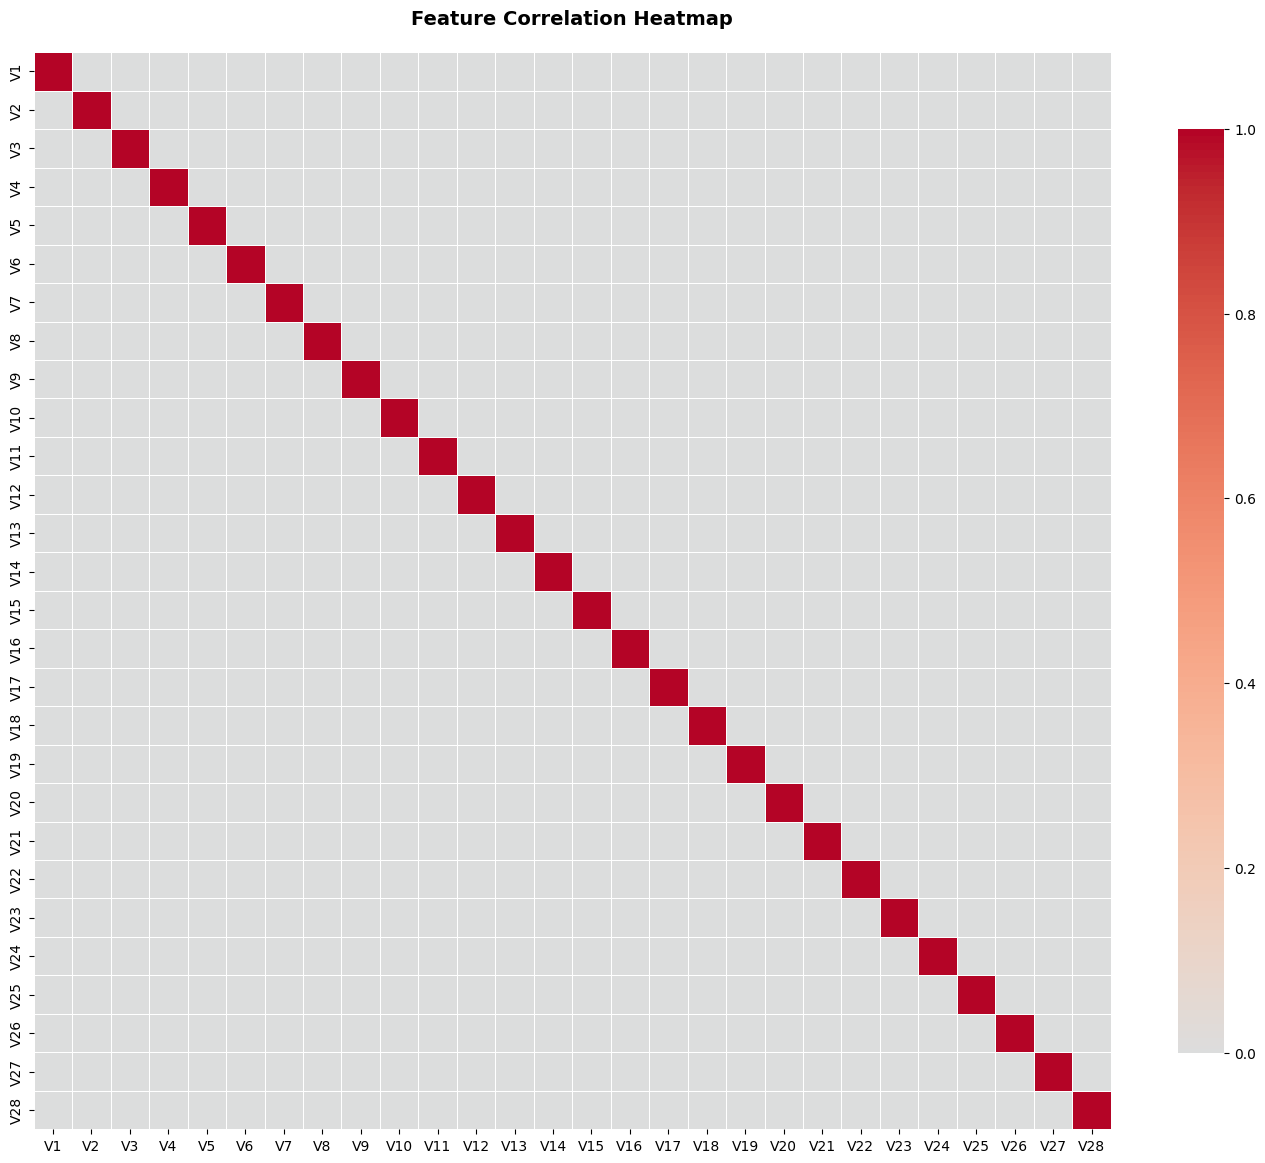


Top 10 Features Correlated with Fraud:
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
dtype: float64

Bottom 10 Features Correlated with Fraud:
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
dtype: float64


In [38]:
# Transaction Amount Analysis
print("\n" + "─" * 70)
print("Transaction Amount Statistics by Class:")
print("─" * 70)
amount_stats = df.groupby("Class")['Amount'].describe()
print(amount_stats)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Amount distribution by class
axes[0, 0].hist(df[df["Class"] == 0]['Amount'], bins=50, alpha=0.6, 
                label='Normal', color='#2ecc71', edgecolor='black')
axes[0, 0].hist(df[df["Class"] == 1]['Amount'], bins=50, alpha=0.6, 
                label='Fraud', color='#e74c3c', edgecolor='black')
axes[0, 0].set_xlabel('Transaction Amount', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Transaction Amount Distribution by Class', 
                      fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Log-scale amount distribution
axes[0, 1].hist(np.log10(df[df["Class"] == 0]['Amount'] + 1), bins=50, 
                alpha=0.6, label='Normal', color='#2ecc71', edgecolor='black')
axes[0, 1].hist(np.log10(df[df["Class"] == 1]['Amount'] + 1), bins=50, 
                alpha=0.6, label='Fraud', color='#e74c3c', edgecolor='black')
axes[0, 1].set_xlabel('Log10(Amount + 1)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Transaction Amount Distribution (Log Scale)', 
                      fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Time distribution
axes[1, 0].hist(df[df["Class"] == 0]['Time'], bins=50, alpha=0.6, 
                label='Normal', color='#2ecc71', edgecolor='black')
axes[1, 0].hist(df[df["Class"] == 1]['Time'], bins=50, alpha=0.6, 
                label='Fraud', color='#e74c3c', edgecolor='black')
axes[1, 0].set_xlabel('Time (seconds)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Transaction Time Distribution', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Box plot for Amount
axes[1, 1].boxplot([df[df["Class"] == 0]['Amount'], 
                     df[df["Class"] == 1]['Amount']],
                    labels=['Normal', 'Fraud'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_ylabel('Transaction Amount', fontsize=11)
axes[1, 1].set_title('Amount Distribution Box Plot', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('phase1_feature_distributions.png', dpi=300, bbox_inches='tight')

plt.show()

# Correlation heatmap (sample of features)

feature_cols = [col for col in df.columns if col not in ["Class", 'Time']]
sample_features = feature_cols[:28] if len(feature_cols) > 15 else feature_cols

correlation_matrix = df[sample_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('phase1_correlation_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()

# Feature correlation with target
target_corr = df[feature_cols].corrwith(df["Class"]).sort_values(ascending=False)
print("\nTop 10 Features Correlated with Fraud:")
print(target_corr.head(10))
print("\nBottom 10 Features Correlated with Fraud:")
print(target_corr.tail(10))